# La Base de las Redes Neuronales Artificiales de Machine Learning

## ¿Qué es el perceptrón?

* El `perceptrón` es un modelo matemático inspirado en las neuronas del cerebro. Fue propuesto por `Frank Rosenblatt` en `1958` y se considera uno de los primeros modelos de redes neuronales.
* Sirve para clasificar datos en `dos categorías`.
* Por ejemplo, puede aprender a `distinguir entre correos "spam" y "no spam" o si una imagen contiene un gato o no`.
* Se llama `clasificación binaria`, porque solo hay dos posibles respuestas: sí (1) o no (0).
* ***“Voy a mirar algunos datos de entrada, los voy a multiplicar por ciertos valores (pesos), los voy a sumar, y si la suma es suficientemente grande, entonces digo sí. Si no, digo no.”***

## Bases del Perceptro

* La elección de los pesos (𝑤𝑖) y el bias (𝑏) es una de las partes más importantes del funcionamiento del perceptrón.
* El objetivo del perceptrón es aprender a clasificar correctamente los datos. Para eso, necesita encontrar los mejores valores posibles para los pesos y el bias.
* `Esto no se hace a mano`. Se hace mediante un proceso automático llamado entrenamiento o `aprendizaje supervisado`.

$$
y = f\left( \sum_{i=1}^{n} w_i x_i + b \right)
$$

donde:

$$x_i \text{ son las entradas (inputs)}$$
$$w_i \text{  son los pesos asignados a cada entrada,}$$
$$b \text{  es el sesgo o bias (valor independiente)}$$
$$f(\cdot) \text{ es la función de activación, típicamente:}$$

$$
f(z) =
\begin{cases}
1 & \text{si } z \geq 0 \\
0 & \text{si } z < 0
\end{cases}
$$


## Entrenamiento supervisado

* ***Paso 1: Se inicia con valores aleatorios***
  - Al principio, los pesos 𝑤𝑖, el bias, 𝑏 se inicializan con valores pequeños y aleatorios (por ejemplo, entre -1 y 1).
  - El perceptrón todavía no "sabe" clasificar bien.

* ***Paso 2: Se usan ejemplos para entrenar***
  - Se le muestran al perceptrón muchos ejemplos con la entrada conocida y la salida deseada (etiqueta).
  - Por ejemplo, un arreglo con todas las caracteristicas y su target.

* ***Paso 3: Se calcula la salida actual***
  - Utilizar la formula del peceptrón.
    
* ***Paso 4: Se compara la salida actual con la salida esperada***
  - Parecido con lo que hacemos en los modelos, tendremos un `yPredict` y el valor real, por lo que se habría que restarlos.

* ***Paso 5: Se actualizan los pesos y el bias***
  - Se repite el proceso con muchos datos de entrenamiento, y poco a poco, el perceptrón va ajustando los pesos y el bias para que las predicciones se acerquen más a los valores correctos.

![FormulaReCalculo.png](FormulaReCalculo.png)

## Creación de un perceptrón

### Datos linealmente separables

* Cuando decimos que los datos son linealmente separables, nos referimos a que es posible separar las clases de un conjunto de datos usando una línea recta (en 2D), un plano (en 3D) o, en general, un hiperplano (en espacios de más dimensiones).
* Un conjunto de datos es linealmente separable si existe un `hiperplano` que divide perfectamente los puntos de distintas clases sin cometer errores de clasificación.

![LinealmenteIndependiente.png](LinealmenteIndependiente.png)

* En 2D, los datos se pueden separar con una línea recta. En 3D, con un plano.

### EJERCICIO EJEMPLO

* Imaginemos que tenemos los siguientes puntos.

| Clase | (x₁, x₂)               |
| :---- | :--------------------- |
| +1    | (1, 2), (2, 3), (3, 3) |
| -1    | (4, 1), (5, 2), (6, 1) |

* Podemos ver como perfectamente los puntos de la clase 1 queda arriba y los de los puntos azules quedan abajo.
* Eso sugiere que una recta descendente podría separarlos, algo así como `𝑥2 = −𝑥1 + 𝑐`.
* Queremos una recta tal que:
  - ***Todos los puntos de clase +1 queden por encima de la recta***.
  - ***Todos los puntos de clase -1 queden por debajo de la recta***.

* Tenemos que estar probrando varias pendientes y valores hasta dar con algún valor que las separe correctamente.
* El perceptrón solo puede converger (es decir, encontrar una solución estable) si los datos son linealmente separables.

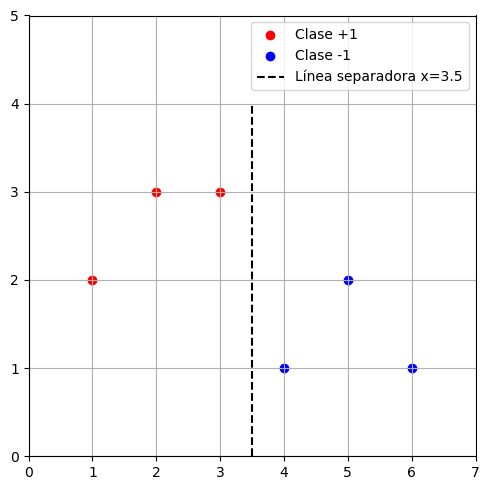

In [1]:
import matplotlib.pyplot as plt
import numpy as np

### Datos linealmente separables
clase1 = np.array([[1, 2], [2, 3], [3,3]])
clase2 = np.array([[4, 1], [5, 2], [6,1]])

### Probar con diferente pendientes
### x = np.random.randint(0, high=7, size=7)
### y = x - 3.5
# Línea separadora vertical x = 3.5
x_sep = np.array([3.5, 3.5])
y_sep = np.array([0, 4])

plt.figure(figsize=(5, 5))
plt.scatter(clase1[:, 0], clase1[:, 1], color='red', label='Clase +1')
plt.scatter(clase2[:, 0], clase2[:, 1], color='blue', label='Clase -1')
plt.plot(x_sep, y_sep, 'k--', label='Línea separadora x=3.5')
plt.xlim(0, 7)
plt.ylim(0, 5)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

* Tenemos el siguiente conjunto de datos, en el cuál buscaremos hacer un sistema que diga si una persona es aplicable para una tarjeta de crédito platinum o no.
* Esto en base a su edad e ingresos actuales.

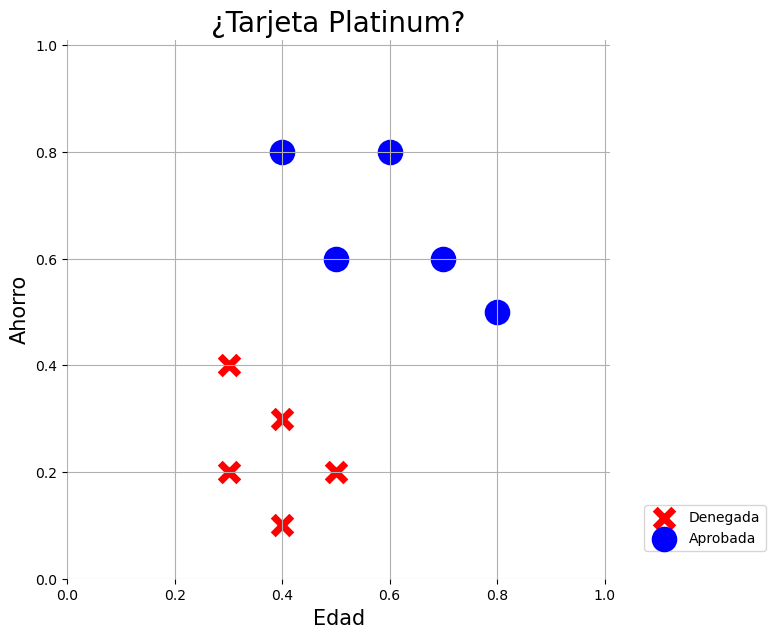

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#### Datos de 10 personas -> [edad, ahorro]
personas = np.array([[0.3, 0.4], [0.4, 0.3],
                     [0.3, 0.2], [0.4, 0.1], 
                     [0.5, 0.2], [0.4, 0.8],
                     [0.6, 0.8], [0.5, 0.6], 
                     [0.7, 0.6], [0.8, 0.5]])

### 1 : aprobrada    0 : denegada
clases = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

### Gráfica de dispersión (edad, ahorro)
plt.figure(figsize=(7, 7))
plt.title("¿Tarjeta Platinum?", fontsize=20)

### Personas que no aplicaron a la TDC.
plt.scatter(personas[clases == 0].T[0], 
            personas[clases == 0].T[1], 
            marker="x", s=180, color="red",
            linewidths=5, label="Denegada")

### Personas que si aplicaron a la TDC.
plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1], 
            marker="o", s=180, color="blue",
            linewidths=5, label="Aprobada")
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.grid()
plt.show()

### Función de Activación (Escalón)

* La función de activación escalón (`step function`) es la más simple y más clásica de todas, y fue la original usada en el perceptrón.
* En una neurona (como el perceptrón), primero se calcula una combinación lineal de las entradas: $$z=w⋅x+b$$
* La función de activación decide qué salida produce la neurona a partir de ese valor `𝑧`. Sirve como una especie de `“interruptor”` o `“puerta”` que transforma la entrada numérica en una salida final.
* La función de activación escalón (`step`):
$$
f(z) =
\begin{cases}
1 & \text{si } z \geq 0 \\
0 & \text{si } z < 0
\end{cases}
$$
* Si la combinación lineal 𝑧 = 𝑤 ⋅ 𝑥 + 𝑏 es positiva, la neurona se “activa” (salida = 1). Si 𝑧 es negativa, la neurona no se activa (salida = 0).
* Es literalmente un interruptor `ON/OFF`.
* La función `np.random.uniform(-1, 1, size=2)` genera valores aleatorios distribuidos uniformemente entre -1 y 1.
* Cada peso `𝑤𝑖` tiene la misma probabilidad de tomar cualquier valor dentro de ese rango. En otras palabras, no preferimos valores positivos ni negativos al inicio.
* Podrías usar distribución normal también `(np.random.randn())`, pero la uniforme es más simple y garantiza que todos los valores en el rango tengan la misma probabilidad.
| Distribución       | Código                        | Característica                                            |
| :----------------- | :---------------------------- | :-------------------------------------------------------- |
| Uniforme           | `np.random.uniform(-1, 1, n)` | Todos los valores dentro del rango son igual de probables |
| Normal (gaussiana) | `np.random.randn(n)`          | Más valores cerca de 0, menos en los extremos             |

![DistribucionUni.png](DistribucionUni.png)

In [12]:
### w1*x1 + w2*x2 + ⋯ + wn*xn
def activacion(weights, x, b):
    z = weights * x
    if z.sum() + b > 0:
        return 1
    else:
        return 0

### Definimos los pesos
weights = np.random.uniform(-1, 1, size=2)
print(f"Weights: {weights}")

### Definimos el sesgo
b = np.random.uniform(-1, 1)
print(f"Bias: {b}")

### un punto (x,y) = (0.5, 0.4) 
print(f"Z={activacion(weights, [0.5, 0.4], b)}")

Weights: [ 0.56206    -0.11788376]
Bias: -0.029117135919167092
Z=1


### Pseudocódigo del Perceptrón

***ALGORITMO BASE DEL PERCEPTRÓN***

0. Inicializar los pesos y el umbral //< Esto lo hicimos arriba con `weights` y `b`.
1. epocas máximas = 100
2. epoca = 0
3. tasa de aprendizaje = 0.01
4. Mientras (epoca < epocas máximas) hacer:
5.      Para cada instancia de entrenamiento hacer:
6.          Calcula salida del perceptrón para esa estancia
7.          Calcula el error
8.          Actualiza pesos y umbral usando la tasa de aprendizaje, la instancia y el error
9.      epoca += 1

***EXPLICACIÓN***
1. Inicializar los pesos y el umbral.
   - Se eligen valores aleatorios pequeños para los pesos 𝑤𝑖 y para el umbral 𝑏.
   - Esto le da al perceptrón un punto de partida en el espacio de soluciones.
2. Definir parámetros del entrenamiento
   - `Épocas máximas`: número de veces que se recorrerá todo el conjunto de entrenamiento.
   - Tasa de aprendizaje (𝜂): controla cuánto cambian los pesos en cada actualización (si es muy alta, el aprendizaje es inestable; si es muy baja, es lento).
3. Ciclo principal de aprendizaje
   - El algoritmo entrena el perceptrón repetidamente, ajustando los pesos hasta que clasifique bien los datos o se cumpla el número máximo de iteraciones.
4. Para cada instancia de entrenamiento
   - Se toma una muestra de datos (un vector de entrada 𝑥𝑖 y su etiqueta real 𝑦𝑖.
5. Calcular la salida del perceptrón
   - Se usa la función de activación escalón. Esto es la predicción del perceptrón para esa entrada.
6. Calcular el error.
   - Si el perceptrón predice bien → error = 0.
   - Si se equivoca → error será +1 o -1
7. Actualizar pesos y umbral.

| Paso | Qué hace                                  | Fórmula principal                              |
| :--- | :---------------------------------------- | :--------------------------------------------- |
| 1    | Inicializar pesos y bias                  | ( w_i, b \sim \text{Uniforme}(-1,1) )          |
| 2    | Calcular salida                           | ( \hat{y} = f(\mathbf{w}\cdot\mathbf{x} + b) ) |
| 3    | Calcular error                            | ( e = y - \hat{y} )                            |
| 4    | Actualizar pesos                          | ( w_i := w_i + \eta e x_i )                    |
| 5    | Actualizar umbral                         | ( b := b + \eta e )                            |
| 6    | Repetir hasta converger o alcanzar límite | —                                              |



### Entrenamiento del Perceptrón

In [13]:
### Asignación de pesos
pesos = np.random.uniform(-1, 1, size=2)

### Sesgo
b = np.random.uniform(-1, 1)

### Parametros del perceptrón
tasa_de_aprendizaje = 0.01
epocas = 100

### Personas es el arreglo con los datos [edad, ingreso] <-- [10 pares datos]

### Haremos 100 predicciones por a cada dato?
for epoca in range(epocas):
    error_total = 0
    for i in range(len(personas)):
        ### Hacemos una predección para un punto o persona
        prediccion = activacion(pesos, personas[i], b)
        ### Calculamos el error
        error = clases[i] - prediccion
        error_total += error**2
        pesos[0] += tasa_de_aprendizaje * personas[i][0] * error
        pesos[1] += tasa_de_aprendizaje * personas[i][1] * error
        b += tasa_de_aprendizaje * error 
    print(error_total, end=" ")

activacion(pesos, [0.5, 1], b)

5 5 5 4 4 3 3 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 2 2 2 1 2 2 2 1 2 2 2 2 1 2 2 2 1 2 2 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

1

### Zonas de aprobación: Gráfica de dispersión [edad, ahorro]

* La `zona de aprobación` se refiere a la región del espacio de entrada donde el perceptrón clasifica las entradas como pertenecientes a una determinada clase (por ejemplo, la `clase “1”` o `“positiva”`).

![ZonaAprobacion.png](ZonaAprobacion.png)

In [9]:
personas
clases

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

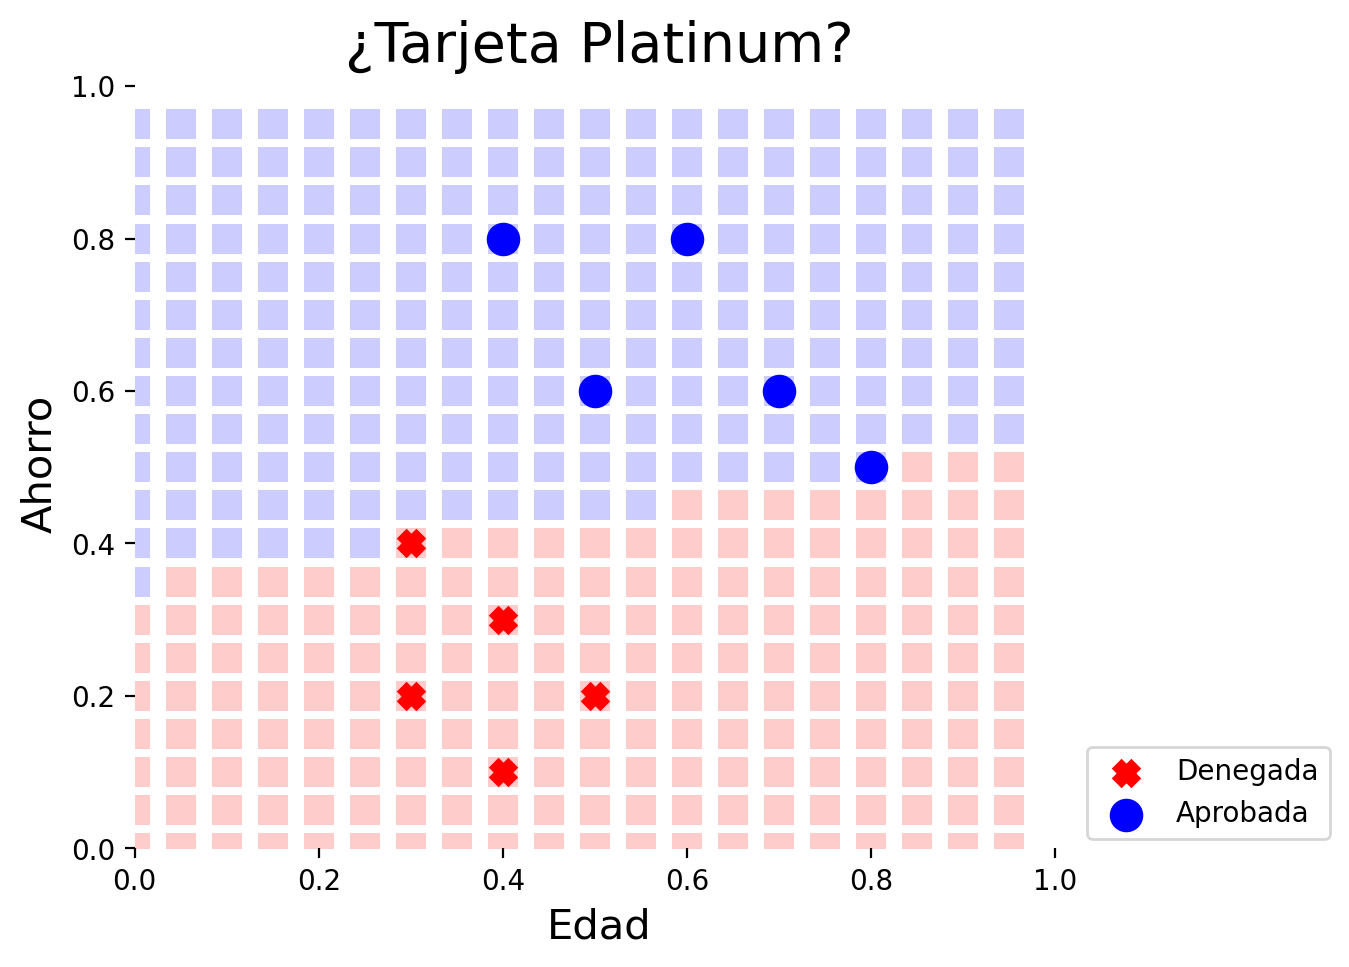

In [17]:
plt.figure(figsize=(6, 5), dpi=200)
plt.title("¿Tarjeta Platinum?", fontsize=20)

### Imprimimos los punto para las personas rechazas
plt.scatter(personas[clases == 0].T[0], 
            personas[clases == 0].T[1], 
            marker="x", s=50, color="red",
            linewidths=5, label="Denegada")
### Imprimimos los punto para las personas aprobadas
plt.scatter(personas[clases == 1].T[0],
            personas[clases == 1].T[1], 
            marker="o", s=50, color="blue",
            linewidths=5, label="Aprobada")

### Rellenamos los cuadros en base a lo que considere el perceptrón
for edad in np.arange(0, 1, 0.05):
    for ahorro in np.arange(0, 1, 0.05):
        ### mandamos a llamar a nuestro perceptrón
        color = activacion(pesos, [edad, ahorro], b)
        if color == 1:
            plt.scatter(edad, ahorro, marker="s", s=110,
                        color="blue", alpha=0.2, linewidths=0)
        else:
            plt.scatter(edad, ahorro, marker="s", s=110, 
                        color="red", alpha=0.2, linewidths=0)
            
plt.xlabel("Edad", fontsize=15)
plt.ylabel("Ahorro", fontsize=15)
plt.legend(bbox_to_anchor=(1.3, 0.15))
plt.box(False)
plt.xlim((0, 1.01))
plt.ylim((0, 1.01))
plt.show()


### Perceptrón con Scikit-learn

* `from sklearn.linear_model import Perceptron`: librería necesaria para mandar a llamar al Perceptrón

In [21]:
from sklearn.linear_model import Perceptron

### Entrenamiento del perceptrón
perceptron = Perceptron().fit(personas, clases)

### Predicción
print(f"Predicción Perceptrón de Sklearn: {perceptron.predict([[0.2, 0.2], [0.8, 0.8]])}")
print(f"Predicción Perceptrón de nuestra: {activacion(pesos,[0.2, 0.2], b)}")
print(f"Predicción Perceptrón de Sklearn: {activacion(pesos, [0.8, 0.8], b)}")

Predicción Perceptrón de Sklearn: [0 1]
Predicción Perceptrón de nuestra: 0
Predicción Perceptrón de Sklearn: 1
